In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv('train-kenlm.csv')
print(df.shape)
print(df.columns)
print(df['label'].value_counts())

(35158, 2)
Index(['text', 'label'], dtype='object')
label
gpt-4-turbo      8801
llama-3.3-70b    8798
gemma-2-27b      8790
human            8769
Name: count, dtype: int64


In [2]:
text_column = 'text'
label_column = 'label'

df_human = df[df[label_column] == 'human']
df_machine = df[df[label_column] != 'human']

print(f"Human: {len(df_human)}")
print(f"Machine: {len(df_machine)}")

Human: 8769
Machine: 26389


In [3]:
train_texts = df_human[text_column].tolist()
print(f"Всего human для обучения: {len(train_texts)}")

Всего human для обучения: 8769


In [4]:
df_llama_train = df[df[label_column].str.contains('llama-3.3-70b', case=False, na=False)]
llama_train_texts = df_llama_train[text_column].tolist()

print(f"Текстов от llama-3.3-70b для обучения: {len(llama_train_texts)}")

train_texts_all = train_texts + llama_train_texts
print(f"Всего текстов для обучения KenLM: {len(train_texts_all)}")
print(f"  - Human: {len(train_texts)}")
print(f"  - Llama: {len(llama_train_texts)}")

Текстов от llama-3.3-70b для обучения: 8798
Всего текстов для обучения KenLM: 17567
  - Human: 8769
  - Llama: 8798


In [5]:
with open('train_texts.txt', 'w', encoding='utf-8') as f:
    for text in train_texts_all:
        if isinstance(text, str) and len(text.strip()) > 0:
            f.write(text.strip() + '\n')

print("train_texts.txt сохранен")
!wc -l train_texts.txt

train_texts.txt сохранен
17566 train_texts.txt


In [6]:
import os
import subprocess

bin_path = os.path.abspath("kenlm-master/build/bin")
lmplz_path = os.path.join(bin_path, "lmplz")
build_binary_path = os.path.join(bin_path, "build_binary")

print("Обучение KenLM модели...")

!{lmplz_path} -o 3 < train_texts.txt > model.arpa
!{build_binary_path} model.arpa model.binary

!ls -lh model.arpa model.binary

import kenlm
model = kenlm.Model('model.binary')
print("Модель успешно загружена!")

Обучение KenLM модели...
=== 1/5 Counting and sorting n-grams ===
Reading /workspace/cloud/experiments/train_texts.txt
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
Unigram tokens 1721611 types 176988
=== 2/5 Calculating and sorting adjusted counts ===
Chain sizes: 1:2123856 2:1141833088 3:2140936960
Statistics:
1 176988 D1=0.6805 D2=1.06138 D3+=1.44008
2 925406 D1=0.831721 D2=1.18424 D3+=1.41394
3 1409221 D1=0.900263 D2=1.31158 D3+=1.4776
Memory estimate for binary LM:
type    MB
probing 49 assuming -p 1.5
probing 55 assuming -r models -p 1.5
trie    23 without quantization
trie    14 assuming -q 8 -b 8 quantization 
trie    22 assuming -a 22 array pointer compression
trie    13 assuming -a 22 -q 8 -b 8 array pointer compression and quantization
=== 3/5 Calculating and sorting initial probabilities ===
Chain sizes: 1:2123856 2:1480

In [9]:
import os
import requests
import json
from pathlib import Path

base_dir = 'ru_hard_dataset'
os.makedirs(base_dir, exist_ok=True)

files_to_download = {
    'essay': [
        ('original_essay.json', 'https://raw.githubusercontent.com/CoffeBank/Ru-hard-detection-dataset/main/main/essay/original_essay.json'),
        ('generated_essays.json', 'https://raw.githubusercontent.com/CoffeBank/Ru-hard-detection-dataset/main/main/essay/generated_essays.json'),
        ('paraphrased_essays.json', 'https://raw.githubusercontent.com/CoffeBank/Ru-hard-detection-dataset/main/main/essay/paraphrased_essays.json')
    ],
    'news': [
        ('original_news.json', 'https://raw.githubusercontent.com/CoffeBank/Ru-hard-detection-dataset/main/main/news/original_news.json'),
        ('generated_news.json', 'https://raw.githubusercontent.com/CoffeBank/Ru-hard-detection-dataset/main/main/news/generated_news.json'),
        ('paraphrased_news.json', 'https://raw.githubusercontent.com/CoffeBank/Ru-hard-detection-dataset/main/main/news/paraphrased_news.json')
    ],
    'scientific_texts': [
        ('orig_scientific.json', 'https://raw.githubusercontent.com/CoffeBank/Ru-hard-detection-dataset/main/main/scientific_texts/orig_scientific.json'),
        ('generated_scientific.json', 'https://raw.githubusercontent.com/CoffeBank/Ru-hard-detection-dataset/main/main/scientific_texts/generated_scientific.json'),
        ('paraphrased_scientific.json', 'https://raw.githubusercontent.com/CoffeBank/Ru-hard-detection-dataset/main/main/scientific_texts/paraphrased_scientific.json')
    ],
    'long_sc': [
        ('rus_scientific_articles_part1.json', 'https://raw.githubusercontent.com/CoffeBank/Ru-hard-detection-dataset/main/long_sc/rus_scientific_articles_part1.json'),
        ('rus_scientific_articles_part2.json', 'https://raw.githubusercontent.com/CoffeBank/Ru-hard-detection-dataset/main/long_sc/rus_scientific_articles_part2.json'),
        ('generated_articles.json', 'https://raw.githubusercontent.com/CoffeBank/Ru-hard-detection-dataset/main/long_sc/generated_articles.json'),
        ('paraphrased_generated_articles.json', 'https://raw.githubusercontent.com/CoffeBank/Ru-hard-detection-dataset/main/long_sc/paraphrased_generated_articles.json')
    ]
}

def download_file(url, save_path):
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        with open(save_path, 'wb') as f:
            f.write(response.content)
        print(f"  ✓ {os.path.basename(save_path)}")
        return True
    except Exception as e:
        print(f"  ✗ {os.path.basename(save_path)} - {str(e)[:50]}")
        return False

total_files = 0
successful_files = 0

for domain, files in files_to_download.items():
    domain_dir = os.path.join(base_dir, domain)
    os.makedirs(domain_dir, exist_ok=True)
    
    print(f"\n📁 {domain.upper()}:")
    
    for filename, url in files:
        save_path = os.path.join(domain_dir, filename)
        if download_file(url, save_path):
            successful_files += 1
        total_files += 1

print(f"\n" + "="*60)
print(f"Загружено {successful_files} из {total_files} файлов")
print(f"Данные сохранены в папке: {base_dir}")
print("="*60)

print("\nСтруктура папок:")
for domain in files_to_download.keys():
    domain_dir = os.path.join(base_dir, domain)
    if os.path.exists(domain_dir):
        files = os.listdir(domain_dir)
        print(f"  {domain}: {len(files)} файлов")


📁 ESSAY:
  ✓ original_essay.json
  ✓ generated_essays.json
  ✓ paraphrased_essays.json

📁 NEWS:
  ✓ original_news.json
  ✓ generated_news.json
  ✓ paraphrased_news.json

📁 SCIENTIFIC_TEXTS:
  ✓ orig_scientific.json
  ✓ generated_scientific.json
  ✓ paraphrased_scientific.json

📁 LONG_SC:
  ✓ rus_scientific_articles_part1.json
  ✓ rus_scientific_articles_part2.json
  ✓ generated_articles.json
  ✓ paraphrased_generated_articles.json

Загружено 13 из 13 файлов
Данные сохранены в папке: ru_hard_dataset

Структура папок:
  essay: 3 файлов
  news: 3 файлов
  scientific_texts: 3 файлов
  long_sc: 4 файлов


In [11]:
import os
import json

base_dir = 'ru_hard_dataset'

for domain in ['news', 'essay', 'scientific_texts', 'long_sc']:
    domain_path = os.path.join(base_dir, domain)
    if os.path.exists(domain_path):
        files = os.listdir(domain_path)
        print(f"\n📁 {domain}: {len(files)} файлов")
        for file in files:
            file_path = os.path.join(domain_path, file)
            size = os.path.getsize(file_path) / 1024  # в KB
            print(f"  - {file} ({size:.1f} KB)")
            
            try:
                with open(file_path, 'r', encoding='utf-8') as f:
                    data = json.load(f)
                    print(f"    Записей: {len(data)}")
                    if len(data) > 0:
                        print(f"    Ключи: {list(data[0].keys())}")
                        print(f"    Пример source: {data[0].get('source', 'не найдено')}")
            except:
                print(f" Ошибка чтения JSON")
    else:
        print(f"\nПапка {domain} не найдена")


📁 news: 3 файлов
  - original_news.json (1225.1 KB)
    Записей: 480
    Ключи: ['id', 'text', 'source', 'dataset']
    Пример source: human
  - paraphrased_news.json (1345.4 KB)
    Записей: 480
    Ключи: ['id', 'text', 'model', 'paraphrasing_type', 'source', 'dataset']
    Пример source: ai+rew
  - generated_news.json (2079.7 KB)
    Записей: 480
    Ключи: ['id', 'text', 'model', 'source', 'dataset']
    Пример source: ai

📁 essay: 3 файлов
  - paraphrased_essays.json (2603.9 KB)
    Записей: 480
    Ключи: ['id', 'text', 'model', 'paraphrasing_type', 'source', 'dataset']
    Пример source: ai+rew
  - original_essay.json (2734.9 KB)
    Записей: 480
    Ключи: ['id', 'text', 'source', 'dataset']
    Пример source: human
  - generated_essays.json (4164.6 KB)
    Записей: 480
    Ключи: ['id', 'text', 'model', 'source', 'dataset']
    Пример source: ai

📁 scientific_texts: 3 файлов
  - paraphrased_scientific.json (10214.5 KB)
    Записей: 479
    Ключи: ['id', 'text', 'model', 'para

In [25]:
import json
import os
import numpy as np
from sklearn.model_selection import train_test_split

def load_domain_data(domain_name, use_original=True, use_generated=True):
    base_dir = 'ru_hard_dataset'
    domain_path = os.path.join(base_dir, domain_name)
    
    human_texts = []
    generated_texts = []
    
    file_mapping = {
        'news': {
            'human': 'original_news.json',
            'generated': 'generated_news.json'
        },
        'essay': {
            'human': 'original_essay.json',
            'generated': 'generated_essays.json'
        },
        'scientific_texts': {
            'human': 'orig_scientific.json',
            'generated': 'generated_scientific.json'
        },
        'long_sc': {
            'human': ['rus_scientific_articles_part1.json', 'rus_scientific_articles_part2.json'],
            'generated': 'generated_articles.json'
        }
    }
    
    if domain_name not in file_mapping:
        print(f"Домен {domain_name} не найден")
        return [], []
    
    if use_original:
        human_files = file_mapping[domain_name]['human']
        if isinstance(human_files, list):
            for hf in human_files:
                file_path = os.path.join(domain_path, hf)
                if os.path.exists(file_path):
                    with open(file_path, 'r', encoding='utf-8') as f:
                        data = json.load(f)
                        for item in data:
                            if item.get('source') == 'human':
                                human_texts.append(item['text'])
        else:
            file_path = os.path.join(domain_path, human_files)
            if os.path.exists(file_path):
                with open(file_path, 'r', encoding='utf-8') as f:
                    data = json.load(f)
                    for item in data:
                        if item.get('source') == 'human':
                            human_texts.append(item['text'])
    
    if use_generated:
        gen_files = file_mapping[domain_name]['generated']
        if isinstance(gen_files, list):
            for gf in gen_files:
                file_path = os.path.join(domain_path, gf)
                if os.path.exists(file_path):
                    with open(file_path, 'r', encoding='utf-8') as f:
                        data = json.load(f)
                        for item in data:
                            if item.get('source') == 'ai':
                                generated_texts.append(item['text'])
        else:
            file_path = os.path.join(domain_path, gen_files)
            if os.path.exists(file_path):
                with open(file_path, 'r', encoding='utf-8') as f:
                    data = json.load(f)
                    for item in data:
                        if item.get('source') == 'ai':
                            generated_texts.append(item['text'])
    
    print(f"Загружено из {domain_name}:")
    print(f"  Human: {len(human_texts)} текстов")
    print(f"  Generated: {len(generated_texts)} текстов")
    
    return human_texts, generated_texts

In [26]:
def get_perplexity(model, text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return None
    try:
        log_prob = model.score(text)
        words = text.split()
        if len(words) > 0:
            return 2.0 ** (-log_prob / len(words))
        else:
            return None
    except:
        return None

In [66]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

news_human, news_generated = load_domain_data('news')

if len(news_human) > 0 and len(news_generated) > 0:
    human_val, human_test = train_test_split(news_human, test_size=0.5, random_state=42)
    gen_val, gen_test = train_test_split(news_generated, test_size=0.5, random_state=42)

    print(f"\n" + "="*60)
    print(f"Валидация")
    print("="*60)
    
    print(f"\nNews - разделение данных:")
    print(f"  Валидация: human={len(human_val)}, generated={len(gen_val)}")
    print(f"  Тест: human={len(human_test)}, generated={len(gen_test)}")
    
    val_human_ppl = []
    for text in human_val:
        ppl = get_perplexity(model, text)
        if ppl is not None:
            val_human_ppl.append(ppl)
    
    val_gen_ppl = []
    for text in gen_val:
        ppl = get_perplexity(model, text)
        if ppl is not None:
            val_gen_ppl.append(ppl)
    
    print(f"\nВалидация - статистика:")
    print(f"  Human ppl: {len(val_human_ppl)} текстов, среднее={np.mean(val_human_ppl):.2f}")
    print(f"  Generated ppl: {len(val_gen_ppl)} текстов, среднее={np.mean(val_gen_ppl):.2f}")
    
    all_val = np.array(val_human_ppl + val_gen_ppl)
    y_val = [0] * len(val_human_ppl) + [1] * len(val_gen_ppl)
    
    thresholds = np.linspace(min(all_val), max(all_val), 200)
    
    best_acc = 0
    best_thresh_acc = None
    for thresh in thresholds:
        y_pred = [1 if ppl < thresh else 0 for ppl in all_val]
        acc = accuracy_score(y_val, y_pred)
        if acc > best_acc:
            best_acc = acc
            best_thresh_acc = thresh
    
    best_f1 = 0
    best_thresh_f1 = None
    for thresh in thresholds:
        y_pred = [1 if ppl < thresh else 0 for ppl in all_val]
        f1 = f1_score(y_val, y_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh_f1 = thresh
    
    y_score = -all_val
    val_auc = roc_auc_score(y_val, y_score)
    fpr, tpr, roc_thresholds = roc_curve(y_val, y_score)
    youden = tpr - fpr
    best_idx = np.argmax(youden)
    best_thresh_youden = -roc_thresholds[best_idx]
    
    print(f"\nNews - пороги (на валидации):")
    print(f"  Accuracy: {best_thresh_acc:.2f} (acc={best_acc:.4f})")
    print(f"  F1:       {best_thresh_f1:.2f} (f1={best_f1:.4f})")
    print(f"  ROC-AUC:   {best_thresh_youden:.2f} (auc={val_auc:.4f})")
    
    print(f"\n" + "="*60)
    print(f"Тестирование")
    print("="*60)
    
    test_human_ppl = []
    for text in human_test:
        ppl = get_perplexity(model, text)
        if ppl is not None:
            test_human_ppl.append(ppl)
    
    test_gen_ppl = []
    for text in gen_test:
        ppl = get_perplexity(model, text)
        if ppl is not None:
            test_gen_ppl.append(ppl)
    
    threshold_f1 = best_thresh_f1
    print(f"\nИспользуем порог по F1: {threshold_f1:.2f}")
    
    all_test = np.array(test_human_ppl + test_gen_ppl)
    y_test = [0] * len(test_human_ppl) + [1] * len(test_gen_ppl)
    
    y_pred_test = [1 if ppl < threshold_f1 else 0 for ppl in all_test]
    
    test_acc = accuracy_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test)
    test_auc = roc_auc_score(y_test, -all_test)
    
    print(f"\nРезультаты на тесте (News):")
    print(f"  Accuracy: {test_acc:.4f}")
    print(f"  F1-score: {test_f1:.4f}")
    print(f"  ROC-AUC:  {test_auc:.4f}")
    
else:
    print("Не удалось загрузить данные для news")

Загружено из news:
  Human: 480 текстов
  Generated: 480 текстов

Валидация

News - разделение данных:
  Валидация: human=240, generated=240
  Тест: human=240, generated=240

Валидация - статистика:
  Human ppl: 240 текстов, среднее=23.18
  Generated ppl: 240 текстов, среднее=18.71

News - пороги (на валидации):
  Accuracy: 21.81 (acc=0.7271)
  F1:       22.31 (f1=0.7528)
  ROC-AUC:   21.51 (auc=0.7895)

Тестирование

Используем порог по F1: 22.31

Результаты на тесте (News):
  Accuracy: 0.7083
  F1-score: 0.7297
  ROC-AUC:  0.7990


In [67]:
print(f"{'Метрика':<12} {'Валидация':>10} {'Тест':>10} {'Разница':>10}")
print("-"*50)
print(f"{'F1-score':<12} {best_f1:>10.4f} {test_f1:>10.4f} {test_f1 - best_f1:>+10.4f}")
print(f"{'Accuracy':<12} {best_acc:>10.4f} {test_acc:>10.4f} {test_acc - best_acc:>+10.4f}")
print(f"{'ROC-AUC':<12} {val_auc:>10.4f} {test_auc:>10.4f} {test_auc - val_auc:>+10.4f}")
news_results = {
    'threshold_f1': best_thresh_f1,
    'threshold_acc': best_thresh_acc,
    'threshold_youden': best_thresh_youden,
    'val_acc': best_acc,
    'val_f1': best_f1,
    'val_auc': val_auc,
    'test_acc': test_acc,
    'test_f1': test_f1,
    'test_auc': test_auc,
    'n_human_val': len(val_human_ppl),
    'n_gen_val': len(val_gen_ppl),
    'n_human_test': len(test_human_ppl),
    'n_gen_test': len(test_gen_ppl)
}

Метрика       Валидация       Тест    Разница
--------------------------------------------------
F1-score         0.7528     0.7297    -0.0231
Accuracy         0.7271     0.7083    -0.0187
ROC-AUC          0.7895     0.7990    +0.0094


/tmp/ipykernel_18502/1263190105.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, labels=['human', 'generated'], patch_artist=True)


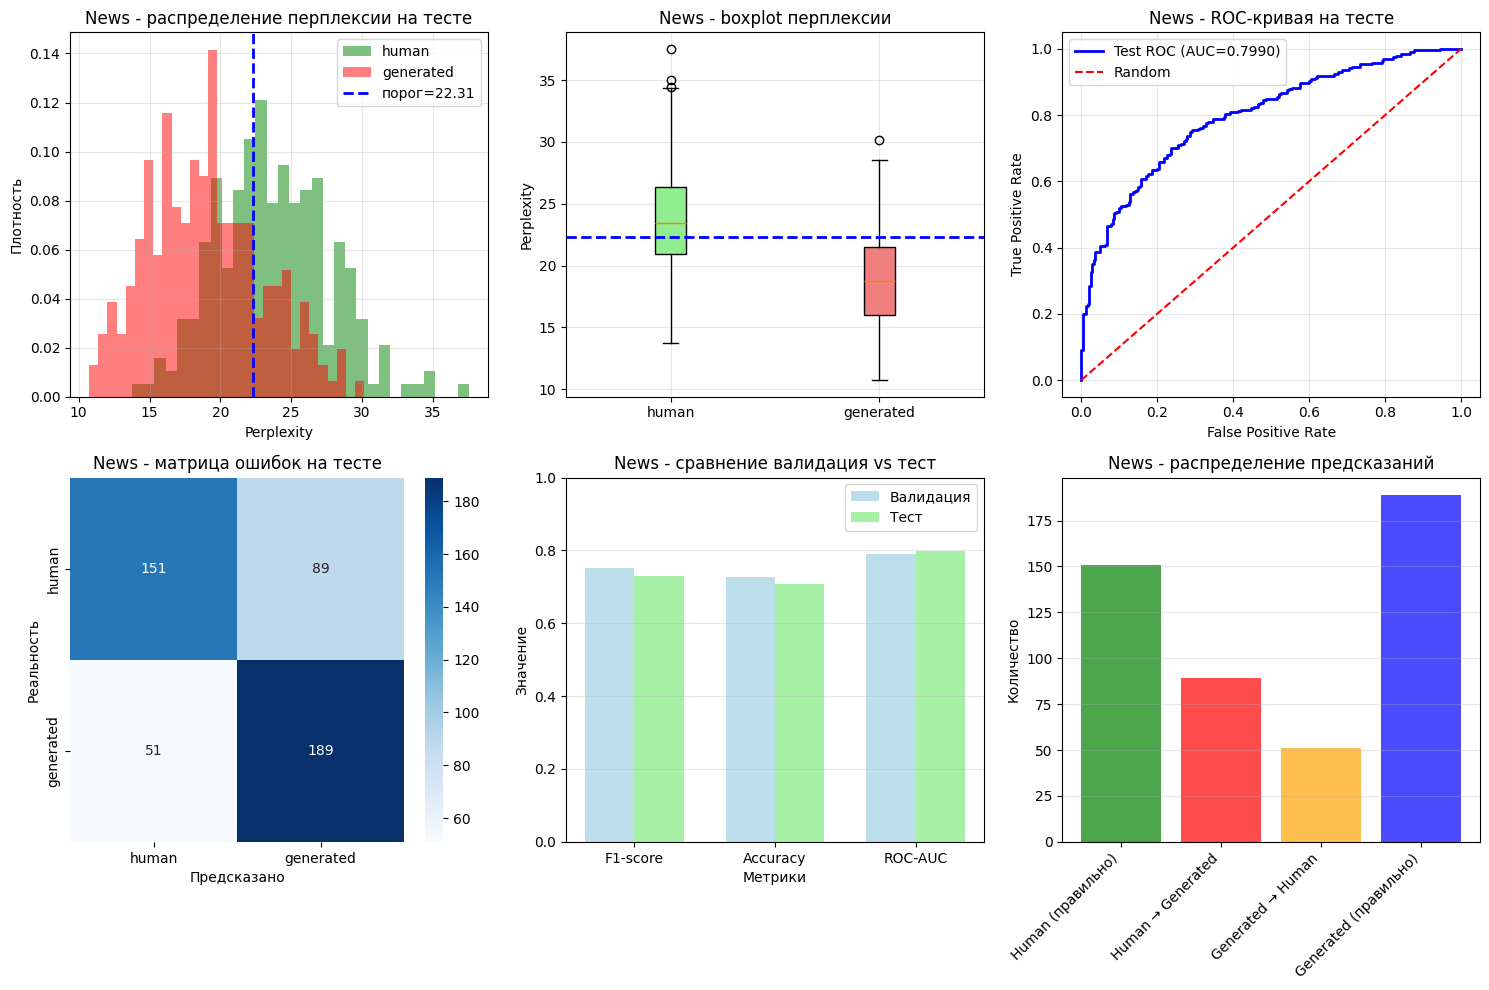

In [68]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, confusion_matrix
import seaborn as sns

test_human_ppl = test_human_ppl 
test_machine_ppl = test_gen_ppl 
y_test_true = [0]*len(test_human_ppl) + [1]*len(test_machine_ppl)
y_test_score = -np.array(test_human_ppl + test_machine_ppl)
final_threshold = best_thresh_f1

plt.figure(figsize=(15, 10))

# 1. Распределение перплексии на тесте
plt.subplot(2, 3, 1)
plt.hist(test_human_ppl, bins=30, alpha=0.5, label='human', density=True, color='green')
plt.hist(test_machine_ppl, bins=30, alpha=0.5, label='generated', density=True, color='red')
plt.axvline(x=final_threshold, color='blue', linestyle='--', linewidth=2, 
            label=f'порог={final_threshold:.2f}')
plt.xlabel('Perplexity')
plt.ylabel('Плотность')
plt.title('News - распределение перплексии на тесте')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Boxplot
plt.subplot(2, 3, 2)
data_to_plot = [test_human_ppl, test_machine_ppl]
bp = plt.boxplot(data_to_plot, labels=['human', 'generated'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
plt.axhline(y=final_threshold, color='blue', linestyle='--', linewidth=2)
plt.ylabel('Perplexity')
plt.title('News - boxplot перплексии')
plt.grid(True, alpha=0.3)

# 3. ROC-кривая
plt.subplot(2, 3, 3)
fpr_test, tpr_test, _ = roc_curve(y_test_true, y_test_score)
plt.plot(fpr_test, tpr_test, 'b-', linewidth=2, label=f'Test ROC (AUC={test_auc:.4f})')
plt.plot([0,1], [0,1], 'r--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('News - ROC-кривая на тесте')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Матрица ошибок
plt.subplot(2, 3, 4)
cm = confusion_matrix(y_test_true, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['human', 'generated'], 
            yticklabels=['human', 'generated'])
plt.xlabel('Предсказано')
plt.ylabel('Реальность')
plt.title('News - матрица ошибок на тесте')

# 5. Сравнение метрик валидация vs тест
plt.subplot(2, 3, 5)
metrics = ['F1-score', 'Accuracy', 'ROC-AUC']
val_values = [best_f1, best_acc, val_auc]
test_values = [test_f1, test_acc, test_auc]
x = np.arange(len(metrics))
width = 0.35
plt.bar(x - width/2, val_values, width, label='Валидация', color='lightblue', alpha=0.8)
plt.bar(x + width/2, test_values, width, label='Тест', color='lightgreen', alpha=0.8)
plt.xlabel('Метрики')
plt.ylabel('Значение')
plt.title('News - сравнение валидация vs тест')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.ylim([0, 1])

# 6. Предсказания по классам
plt.subplot(2, 3, 6)
labels = ['Human (правильно)', 'Human → Generated', 'Generated → Human', 'Generated (правильно)']
values = [cm[0,0], cm[0,1], cm[1,0], cm[1,1]]
colors = ['green', 'red', 'orange', 'blue']
plt.bar(labels, values, color=colors, alpha=0.7)
plt.ylabel('Количество')
plt.title('News - распределение предсказаний')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [69]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

essay_human, essay_generated = load_domain_data('essay')

if len(essay_human) > 0 and len(essay_generated) > 0:
    human_val, human_test = train_test_split(essay_human, test_size=0.5, random_state=42)
    gen_val, gen_test = train_test_split(essay_generated, test_size=0.5, random_state=42)
    print(f"\n" + "="*60)
    print(f"Валидация")
    print("="*60)
    print(f"\nEssay - разделение данных:")
    print(f"  Валидация: human={len(human_val)}, generated={len(gen_val)}")
    print(f"  Тест: human={len(human_test)}, generated={len(gen_test)}")
    
    val_human_ppl = []
    for text in human_val:
        ppl = get_perplexity(model, text)
        if ppl is not None:
            val_human_ppl.append(ppl)
    
    val_gen_ppl = []
    for text in gen_val:
        ppl = get_perplexity(model, text)
        if ppl is not None:
            val_gen_ppl.append(ppl)
    
    print(f"\nВалидация - статистика:")
    print(f"  Human ppl: {len(val_human_ppl)} текстов, среднее={np.mean(val_human_ppl):.2f}")
    print(f"  Generated ppl: {len(val_gen_ppl)} текстов, среднее={np.mean(val_gen_ppl):.2f}")
    
    all_val = np.array(val_human_ppl + val_gen_ppl)
    y_val = [0] * len(val_human_ppl) + [1] * len(val_gen_ppl)
    
    thresholds = np.linspace(min(all_val), max(all_val), 200)
    
    best_acc = 0
    best_thresh_acc = None
    for thresh in thresholds:
        y_pred = [1 if ppl < thresh else 0 for ppl in all_val]
        acc = accuracy_score(y_val, y_pred)
        if acc > best_acc:
            best_acc = acc
            best_thresh_acc = thresh
    
    best_f1 = 0
    best_thresh_f1 = None
    for thresh in thresholds:
        y_pred = [1 if ppl < thresh else 0 for ppl in all_val]
        f1 = f1_score(y_val, y_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh_f1 = thresh
    
    y_score = -all_val
    val_auc = roc_auc_score(y_val, y_score)
    fpr, tpr, roc_thresholds = roc_curve(y_val, y_score)
    youden = tpr - fpr
    best_idx = np.argmax(youden)
    best_thresh_youden = -roc_thresholds[best_idx]
    
    print(f"\nEssay - пороги (на валидации):")
    print(f"  Accuracy: {best_thresh_acc:.2f} (acc={best_acc:.4f})")
    print(f"  F1:       {best_thresh_f1:.2f} (f1={best_f1:.4f})")
    print(f"  ROC-AUC:   {best_thresh_youden:.2f} (auc={val_auc:.4f})")
    
    print(f"\n" + "="*60)
    print(f"Тестирование")
    print("="*60)
    
    test_human_ppl = []
    for text in human_test:
        ppl = get_perplexity(model, text)
        if ppl is not None:
            test_human_ppl.append(ppl)
    
    test_gen_ppl = []
    for text in gen_test:
        ppl = get_perplexity(model, text)
        if ppl is not None:
            test_gen_ppl.append(ppl)
    
    threshold_f1 = best_thresh_f1
    print(f"\nИспользуем порог по F1: {threshold_f1:.2f}")
    
    all_test = np.array(test_human_ppl + test_gen_ppl)
    y_test = [0] * len(test_human_ppl) + [1] * len(test_gen_ppl)
    
    y_pred_test = [1 if ppl < threshold_f1 else 0 for ppl in all_test]
    
    test_acc = accuracy_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test)
    test_auc = roc_auc_score(y_test, -all_test)
    
    print(f"\nРезультаты на тесте (Essay):")
    print(f"  Accuracy: {test_acc:.4f}")
    print(f"  F1-score: {test_f1:.4f}")
    print(f"  ROC-AUC:  {test_auc:.4f}")
    
else:
    print("Не удалось загрузить данные для essay")

Загружено из essay:
  Human: 480 текстов
  Generated: 480 текстов

Валидация

Essay - разделение данных:
  Валидация: human=240, generated=240
  Тест: human=240, generated=240

Валидация - статистика:
  Human ppl: 240 текстов, среднее=21.12
  Generated ppl: 240 текстов, среднее=17.01

Essay - пороги (на валидации):
  Accuracy: 17.83 (acc=0.8187)
  F1:       17.92 (f1=0.7963)
  ROC-AUC:   17.93 (auc=0.8300)

Тестирование

Используем порог по F1: 17.92

Результаты на тесте (Essay):
  Accuracy: 0.7958
  F1-score: 0.7742
  ROC-AUC:  0.8256


In [70]:
print(f"{'Метрика':<12} {'Валидация':>10} {'Тест':>10} {'Разница':>10}")
print("-"*50)
print(f"{'F1-score':<12} {best_f1:>10.4f} {test_f1:>10.4f} {test_f1 - best_f1:>+10.4f}")
print(f"{'Accuracy':<12} {best_acc:>10.4f} {test_acc:>10.4f} {test_acc - best_acc:>+10.4f}")
print(f"{'ROC-AUC':<12} {val_auc:>10.4f} {test_auc:>10.4f} {test_auc - val_auc:>+10.4f}")
essay_results = {
    'threshold_f1': best_thresh_f1,
    'threshold_acc': best_thresh_acc,
    'threshold_youden': best_thresh_youden,
    'val_acc': best_acc,
    'val_f1': best_f1,
    'val_auc': val_auc,
    'test_acc': test_acc,
    'test_f1': test_f1,
    'test_auc': test_auc,
    'n_human_val': len(val_human_ppl),
    'n_gen_val': len(val_gen_ppl),
    'n_human_test': len(test_human_ppl),
    'n_gen_test': len(test_gen_ppl)
}

Метрика       Валидация       Тест    Разница
--------------------------------------------------
F1-score         0.7963     0.7742    -0.0221
Accuracy         0.8187     0.7958    -0.0229
ROC-AUC          0.8300     0.8256    -0.0044


/tmp/ipykernel_18502/3772870104.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, labels=['human', 'generated'], patch_artist=True)


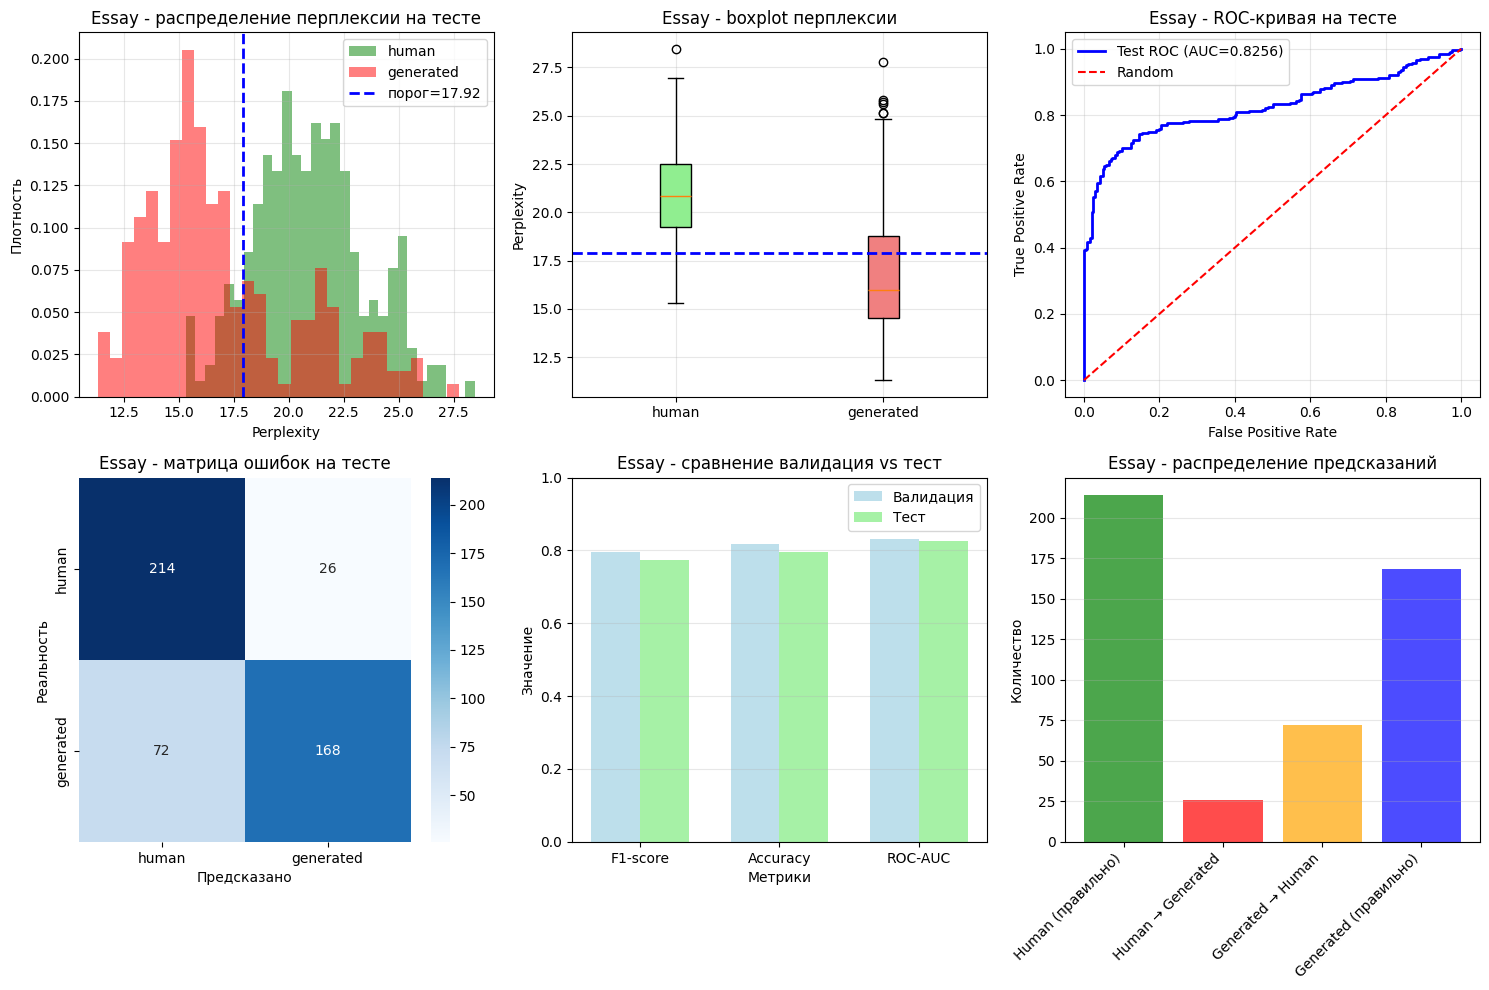

In [71]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, confusion_matrix
import seaborn as sns

test_human_ppl = test_human_ppl 
test_machine_ppl = test_gen_ppl 
y_test_true = [0]*len(test_human_ppl) + [1]*len(test_machine_ppl)
y_test_score = -np.array(test_human_ppl + test_machine_ppl)
final_threshold = best_thresh_f1

plt.figure(figsize=(15, 10))

# 1. Распределение перплексии на тесте
plt.subplot(2, 3, 1)
plt.hist(test_human_ppl, bins=30, alpha=0.5, label='human', density=True, color='green')
plt.hist(test_machine_ppl, bins=30, alpha=0.5, label='generated', density=True, color='red')
plt.axvline(x=final_threshold, color='blue', linestyle='--', linewidth=2, 
            label=f'порог={final_threshold:.2f}')
plt.xlabel('Perplexity')
plt.ylabel('Плотность')
plt.title('Essay - распределение перплексии на тесте')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Boxplot
plt.subplot(2, 3, 2)
data_to_plot = [test_human_ppl, test_machine_ppl]
bp = plt.boxplot(data_to_plot, labels=['human', 'generated'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
plt.axhline(y=final_threshold, color='blue', linestyle='--', linewidth=2)
plt.ylabel('Perplexity')
plt.title('Essay - boxplot перплексии')
plt.grid(True, alpha=0.3)

# 3. ROC-кривая
plt.subplot(2, 3, 3)
fpr_test, tpr_test, _ = roc_curve(y_test_true, y_test_score)
plt.plot(fpr_test, tpr_test, 'b-', linewidth=2, label=f'Test ROC (AUC={test_auc:.4f})')
plt.plot([0,1], [0,1], 'r--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Essay - ROC-кривая на тесте')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Матрица ошибок
plt.subplot(2, 3, 4)
cm = confusion_matrix(y_test_true, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['human', 'generated'], 
            yticklabels=['human', 'generated'])
plt.xlabel('Предсказано')
plt.ylabel('Реальность')
plt.title('Essay - матрица ошибок на тесте')

# 5. Сравнение метрик валидация vs тест
plt.subplot(2, 3, 5)
metrics = ['F1-score', 'Accuracy', 'ROC-AUC']
val_values = [best_f1, best_acc, val_auc]
test_values = [test_f1, test_acc, test_auc]
x = np.arange(len(metrics))
width = 0.35
plt.bar(x - width/2, val_values, width, label='Валидация', color='lightblue', alpha=0.8)
plt.bar(x + width/2, test_values, width, label='Тест', color='lightgreen', alpha=0.8)
plt.xlabel('Метрики')
plt.ylabel('Значение')
plt.title('Essay - сравнение валидация vs тест')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.ylim([0, 1])

# 6. Предсказания по классам
plt.subplot(2, 3, 6)
labels = ['Human (правильно)', 'Human → Generated', 'Generated → Human', 'Generated (правильно)']
values = [cm[0,0], cm[0,1], cm[1,0], cm[1,1]]
colors = ['green', 'red', 'orange', 'blue']
plt.bar(labels, values, color=colors, alpha=0.7)
plt.ylabel('Количество')
plt.title('Essay - распределение предсказаний')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [72]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

sci_human, sci_generated = load_domain_data('scientific_texts')

if len(sci_human) > 0 and len(sci_generated) > 0:
    human_val, human_test = train_test_split(sci_human, test_size=0.5, random_state=42)
    gen_val, gen_test = train_test_split(sci_generated, test_size=0.5, random_state=42)
    print(f"\n" + "="*60)
    print(f"Валидация")
    print("="*60)
    print(f"\nScientific - разделение данных:")
    print(f"  Валидация: human={len(human_val)}, generated={len(gen_val)}")
    print(f"  Тест: human={len(human_test)}, generated={len(gen_test)}")
    
    val_human_ppl = []
    for text in human_val:
        ppl = get_perplexity(model, text)
        if ppl is not None:
            val_human_ppl.append(ppl)
    
    val_gen_ppl = []
    for text in gen_val:
        ppl = get_perplexity(model, text)
        if ppl is not None:
            val_gen_ppl.append(ppl)
    
    print(f"\nВалидация - статистика:")
    print(f"  Human ppl: {len(val_human_ppl)} текстов, среднее={np.mean(val_human_ppl):.2f}")
    print(f"  Generated ppl: {len(val_gen_ppl)} текстов, среднее={np.mean(val_gen_ppl):.2f}")
    
    all_val = np.array(val_human_ppl + val_gen_ppl)
    y_val = [0] * len(val_human_ppl) + [1] * len(val_gen_ppl)
    
    thresholds = np.linspace(min(all_val), max(all_val), 200)
    
    best_acc = 0
    best_thresh_acc = None
    for thresh in thresholds:
        y_pred = [1 if ppl < thresh else 0 for ppl in all_val]
        acc = accuracy_score(y_val, y_pred)
        if acc > best_acc:
            best_acc = acc
            best_thresh_acc = thresh
    
    best_f1 = 0
    best_thresh_f1 = None
    for thresh in thresholds:
        y_pred = [1 if ppl < thresh else 0 for ppl in all_val]
        f1 = f1_score(y_val, y_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh_f1 = thresh
    
    y_score = -all_val
    val_auc = roc_auc_score(y_val, y_score)
    fpr, tpr, roc_thresholds = roc_curve(y_val, y_score)
    youden = tpr - fpr
    best_idx = np.argmax(youden)
    best_thresh_youden = -roc_thresholds[best_idx]
    
    print(f"\nScientific - пороги (на валидации):")
    print(f"  Accuracy: {best_thresh_acc:.2f} (acc={best_acc:.4f})")
    print(f"  F1:       {best_thresh_f1:.2f} (f1={best_f1:.4f})")
    print(f"  ROC-AUC:   {best_thresh_youden:.2f} (auc={val_auc:.4f})")
    
    print(f"\n" + "="*60)
    print(f"Тестирование")
    print("="*60)
    
    test_human_ppl = []
    for text in human_test:
        ppl = get_perplexity(model, text)
        if ppl is not None:
            test_human_ppl.append(ppl)
    
    test_gen_ppl = []
    for text in gen_test:
        ppl = get_perplexity(model, text)
        if ppl is not None:
            test_gen_ppl.append(ppl)
    
    # Используем порог по Accuracy
    threshold_acc = best_thresh_acc
    print(f"\nИспользуем порог по Accuracy: {threshold_acc:.2f}")
    
    all_test = np.array(test_human_ppl + test_gen_ppl)
    y_test = [0] * len(test_human_ppl) + [1] * len(test_gen_ppl)
    
    y_pred_test = [1 if ppl < threshold_acc else 0 for ppl in all_test]
    
    test_acc = accuracy_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test)
    test_auc = roc_auc_score(y_test, -all_test)
    
    print(f"\nРезультаты на тесте (Scientific):")
    print(f"  Accuracy: {test_acc:.4f}")
    print(f"  F1-score: {test_f1:.4f}")
    print(f"  ROC-AUC:  {test_auc:.4f}")
    
else:
    print("Не удалось загрузить данные для scientific_texts")

Загружено из scientific_texts:
  Human: 479 текстов
  Generated: 479 текстов

Валидация

Scientific - разделение данных:
  Валидация: human=239, generated=239
  Тест: human=240, generated=240

Валидация - статистика:
  Human ppl: 239 текстов, среднее=16.87
  Generated ppl: 239 текстов, среднее=12.76

Scientific - пороги (на валидации):
  Accuracy: 13.68 (acc=0.7469)
  F1:       16.00 (f1=0.7378)
  ROC-AUC:   13.63 (auc=0.8100)

Тестирование

Используем порог по Accuracy: 13.68

Результаты на тесте (Scientific):
  Accuracy: 0.7417
  F1-score: 0.7304
  ROC-AUC:  0.8073


In [73]:
print(f"{'Метрика':<12} {'Валидация':>10} {'Тест':>10} {'Разница':>10}")
print("-"*50)
print(f"{'F1-score':<12} {best_f1:>10.4f} {test_f1:>10.4f} {test_f1 - best_f1:>+10.4f}")
print(f"{'Accuracy':<12} {best_acc:>10.4f} {test_acc:>10.4f} {test_acc - best_acc:>+10.4f}")
print(f"{'ROC-AUC':<12} {val_auc:>10.4f} {test_auc:>10.4f} {test_auc - val_auc:>+10.4f}")
sci_results = {
    'threshold_f1': best_thresh_f1,
    'threshold_acc': best_thresh_acc,
    'threshold_youden': best_thresh_youden,
    'val_acc': best_acc,
    'val_f1': best_f1,
    'val_auc': val_auc,
    'test_acc': test_acc,
    'test_f1': test_f1,
    'test_auc': test_auc,
    'n_human_val': len(val_human_ppl),
    'n_gen_val': len(val_gen_ppl),
    'n_human_test': len(test_human_ppl),
    'n_gen_test': len(test_gen_ppl)
}

Метрика       Валидация       Тест    Разница
--------------------------------------------------
F1-score         0.7378     0.7304    -0.0074
Accuracy         0.7469     0.7417    -0.0052
ROC-AUC          0.8100     0.8073    -0.0027


/tmp/ipykernel_18502/2071497620.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, labels=['human', 'generated'], patch_artist=True)


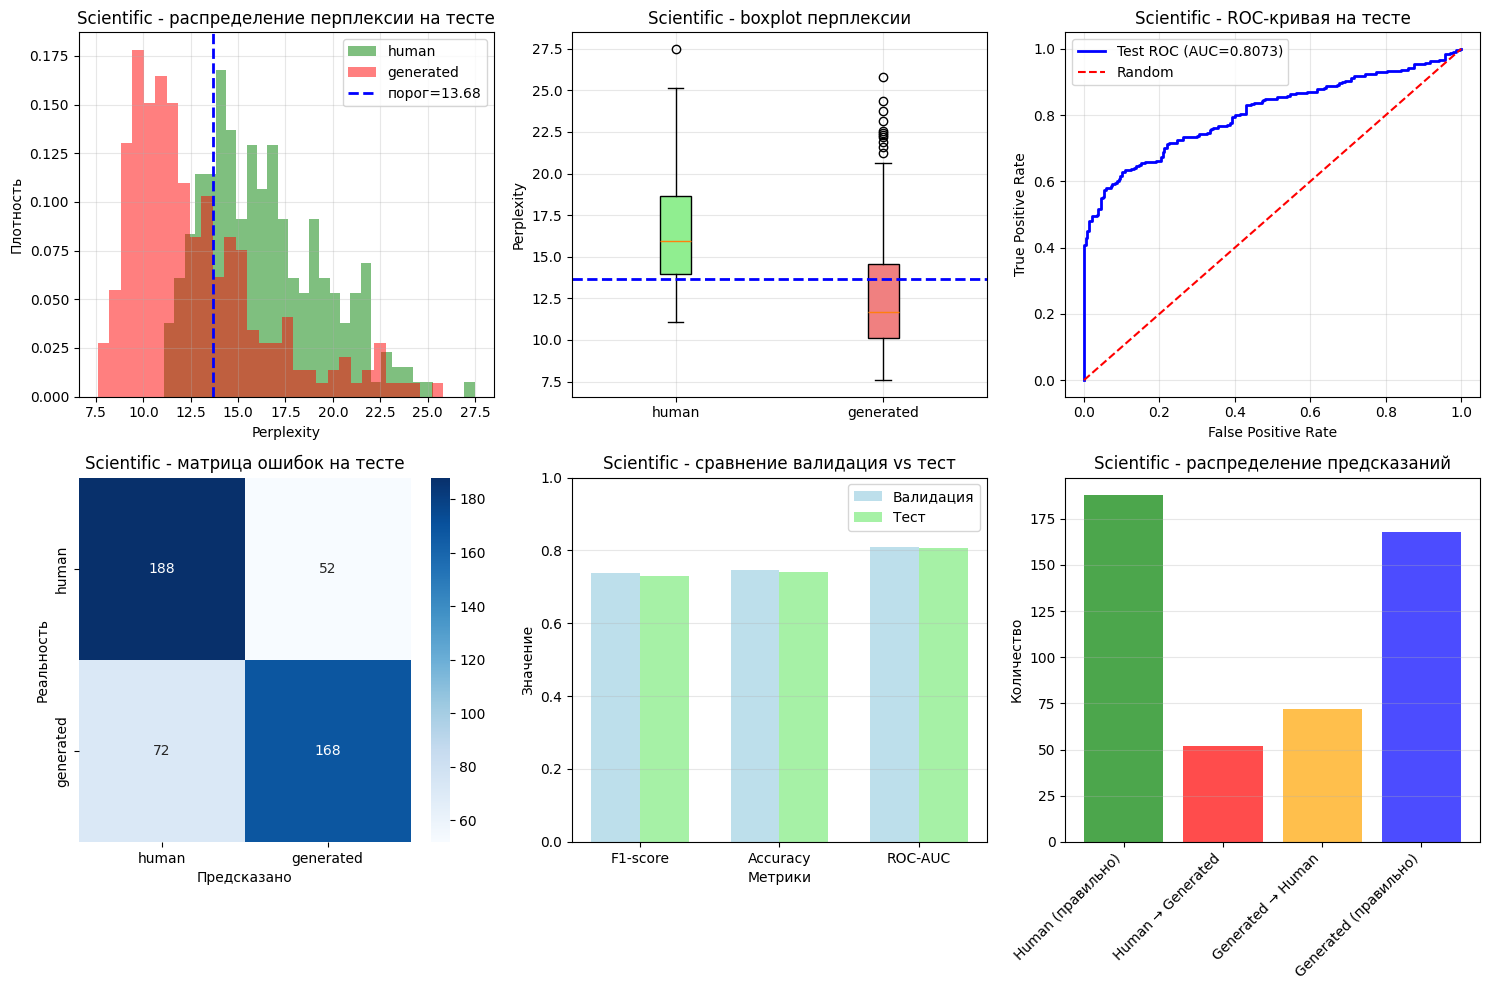

In [74]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, confusion_matrix
import seaborn as sns

# Подготавливаем данные для визуализации
test_human_ppl = test_human_ppl
test_machine_ppl = test_gen_ppl
y_test_true = [0]*len(test_human_ppl) + [1]*len(test_machine_ppl)
y_test_score = -np.array(test_human_ppl + test_machine_ppl)
final_threshold = best_thresh_acc  # используем порог по Accuracy

plt.figure(figsize=(15, 10))

# 1. Распределение перплексии на тесте
plt.subplot(2, 3, 1)
plt.hist(test_human_ppl, bins=30, alpha=0.5, label='human', density=True, color='green')
plt.hist(test_machine_ppl, bins=30, alpha=0.5, label='generated', density=True, color='red')
plt.axvline(x=final_threshold, color='blue', linestyle='--', linewidth=2, 
            label=f'порог={final_threshold:.2f}')
plt.xlabel('Perplexity')
plt.ylabel('Плотность')
plt.title('Scientific - распределение перплексии на тесте')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Boxplot
plt.subplot(2, 3, 2)
data_to_plot = [test_human_ppl, test_machine_ppl]
bp = plt.boxplot(data_to_plot, labels=['human', 'generated'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
plt.axhline(y=final_threshold, color='blue', linestyle='--', linewidth=2)
plt.ylabel('Perplexity')
plt.title('Scientific - boxplot перплексии')
plt.grid(True, alpha=0.3)

# 3. ROC-кривая
plt.subplot(2, 3, 3)
fpr_test, tpr_test, _ = roc_curve(y_test_true, y_test_score)
plt.plot(fpr_test, tpr_test, 'b-', linewidth=2, label=f'Test ROC (AUC={test_auc:.4f})')
plt.plot([0,1], [0,1], 'r--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Scientific - ROC-кривая на тесте')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Матрица ошибок
plt.subplot(2, 3, 4)
cm = confusion_matrix(y_test_true, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['human', 'generated'], 
            yticklabels=['human', 'generated'])
plt.xlabel('Предсказано')
plt.ylabel('Реальность')
plt.title('Scientific - матрица ошибок на тесте')

# 5. Сравнение метрик валидация vs тест
plt.subplot(2, 3, 5)
metrics = ['F1-score', 'Accuracy', 'ROC-AUC']
val_values = [best_f1, best_acc, val_auc]
test_values = [test_f1, test_acc, test_auc]
x = np.arange(len(metrics))
width = 0.35
plt.bar(x - width/2, val_values, width, label='Валидация', color='lightblue', alpha=0.8)
plt.bar(x + width/2, test_values, width, label='Тест', color='lightgreen', alpha=0.8)
plt.xlabel('Метрики')
plt.ylabel('Значение')
plt.title('Scientific - сравнение валидация vs тест')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.ylim([0, 1])

# 6. Предсказания по классам
plt.subplot(2, 3, 6)
labels = ['Human (правильно)', 'Human → Generated', 'Generated → Human', 'Generated (правильно)']
values = [cm[0,0], cm[0,1], cm[1,0], cm[1,1]]
colors = ['green', 'red', 'orange', 'blue']
plt.bar(labels, values, color=colors, alpha=0.7)
plt.ylabel('Количество')
plt.title('Scientific - распределение предсказаний')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [75]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
import random

long_human, long_generated = load_domain_data('long_sc')

if len(long_human) > 0 and len(long_generated) > 0:
    n_samples = min(len(long_human), len(long_generated))
    
    random.seed(42)
    long_human_balanced = random.sample(long_human, n_samples)
    long_generated_balanced = random.sample(long_generated, n_samples)
    
    print(f"\n" + "="*60)
    print(f"Балансировка данных")
    print("="*60)
    print(f"  Human исходно: {len(long_human)}")
    print(f"  Generated исходно: {len(long_generated)}")
    print(f"  Human после балансировки: {len(long_human_balanced)}")
    print(f"  Generated после балансировки: {len(long_generated_balanced)}")
    
    human_val, human_test = train_test_split(long_human_balanced, test_size=0.5, random_state=42)
    gen_val, gen_test = train_test_split(long_generated_balanced, test_size=0.5, random_state=42)
    
    print(f"\n" + "="*60)
    print(f"Валидация")
    print("="*60)
    print(f"\nLong SC - разделение данных:")
    print(f"  Валидация: human={len(human_val)}, generated={len(gen_val)}")
    print(f"  Тест: human={len(human_test)}, generated={len(gen_test)}")
    
    val_human_ppl = []
    for text in human_val:
        ppl = get_perplexity(model, text)
        if ppl is not None:
            val_human_ppl.append(ppl)
    
    val_gen_ppl = []
    for text in gen_val:
        ppl = get_perplexity(model, text)
        if ppl is not None:
            val_gen_ppl.append(ppl)
    
    print(f"\nВалидация - статистика:")
    print(f"  Human ppl: {len(val_human_ppl)} текстов, среднее={np.mean(val_human_ppl):.2f}")
    print(f"  Generated ppl: {len(val_gen_ppl)} текстов, среднее={np.mean(val_gen_ppl):.2f}")
    
    all_val = np.array(val_human_ppl + val_gen_ppl)
    y_val = [0] * len(val_human_ppl) + [1] * len(val_gen_ppl)
    
    thresholds = np.linspace(min(all_val), max(all_val), 200)
    
    best_acc = 0
    best_thresh_acc = None
    for thresh in thresholds:
        y_pred = [1 if ppl < thresh else 0 for ppl in all_val]
        acc = accuracy_score(y_val, y_pred)
        if acc > best_acc:
            best_acc = acc
            best_thresh_acc = thresh
    
    best_f1 = 0
    best_thresh_f1 = None
    for thresh in thresholds:
        y_pred = [1 if ppl < thresh else 0 for ppl in all_val]
        f1 = f1_score(y_val, y_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh_f1 = thresh
    
    y_score = -all_val
    val_auc = roc_auc_score(y_val, y_score)
    fpr, tpr, roc_thresholds = roc_curve(y_val, y_score)
    youden = tpr - fpr
    best_idx = np.argmax(youden)
    best_thresh_youden = -roc_thresholds[best_idx]
    
    print(f"\nLong SC - пороги (на валидации):")
    print(f"  Accuracy: {best_thresh_acc:.2f} (acc={best_acc:.4f})")
    print(f"  F1:       {best_thresh_f1:.2f} (f1={best_f1:.4f})")
    print(f"  ROC-AUC:   {best_thresh_youden:.2f} (auc={val_auc:.4f})")
    
    print(f"\n" + "="*60)
    print(f"Тестирование")
    print("="*60)
    
    test_human_ppl = []
    for text in human_test:
        ppl = get_perplexity(model, text)
        if ppl is not None:
            test_human_ppl.append(ppl)
    
    test_gen_ppl = []
    for text in gen_test:
        ppl = get_perplexity(model, text)
        if ppl is not None:
            test_gen_ppl.append(ppl)
    
    threshold_f1 = best_thresh_f1
    print(f"\nИспользуем порог по F1: {threshold_f1:.2f}")
    
    all_test = np.array(test_human_ppl + test_gen_ppl)
    y_test = [0] * len(test_human_ppl) + [1] * len(test_gen_ppl)
    
    y_pred_test = [1 if ppl < threshold_f1 else 0 for ppl in all_test]
    
    test_acc = accuracy_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test)
    test_auc = roc_auc_score(y_test, -all_test)
    
    print(f"\nРезультаты на тесте (Long SC):")
    print(f"  Accuracy: {test_acc:.4f}")
    print(f"  F1-score: {test_f1:.4f}")
    print(f"  ROC-AUC:  {test_auc:.4f}")
    
else:
    print("Не удалось загрузить данные для long_sc")

Загружено из long_sc:
  Human: 2478 текстов
  Generated: 1449 текстов

Балансировка данных
  Human исходно: 2478
  Generated исходно: 1449
  Human после балансировки: 1449
  Generated после балансировки: 1449

Валидация

Long SC - разделение данных:
  Валидация: human=724, generated=724
  Тест: human=725, generated=725

Валидация - статистика:
  Human ppl: 724 текстов, среднее=24.58
  Generated ppl: 724 текстов, среднее=14.11

Long SC - пороги (на валидации):
  Accuracy: 18.57 (acc=0.9254)
  F1:       19.15 (f1=0.9259)
  ROC-AUC:   18.68 (auc=0.9733)

Тестирование

Используем порог по F1: 19.15

Результаты на тесте (Long SC):
  Accuracy: 0.9248
  F1-score: 0.9254
  ROC-AUC:  0.9691


In [76]:
print(f"{'Метрика':<12} {'Валидация':>10} {'Тест':>10} {'Разница':>10}")
print("-"*50)
print(f"{'F1-score':<12} {best_f1:>10.4f} {test_f1:>10.4f} {test_f1 - best_f1:>+10.4f}")
print(f"{'Accuracy':<12} {best_acc:>10.4f} {test_acc:>10.4f} {test_acc - best_acc:>+10.4f}")
print(f"{'ROC-AUC':<12} {val_auc:>10.4f} {test_auc:>10.4f} {test_auc - val_auc:>+10.4f}")
long_results = {
    'threshold_f1': best_thresh_f1,
    'threshold_acc': best_thresh_acc,
    'threshold_youden': best_thresh_youden,
    'val_acc': best_acc,
    'val_f1': best_f1,
    'val_auc': val_auc,
    'test_acc': test_acc,
    'test_f1': test_f1,
    'test_auc': test_auc,
    'n_human_val': len(val_human_ppl),
    'n_gen_val': len(val_gen_ppl),
    'n_human_test': len(test_human_ppl),
    'n_gen_test': len(test_gen_ppl)
}

Метрика       Валидация       Тест    Разница
--------------------------------------------------
F1-score         0.9259     0.9254    -0.0005
Accuracy         0.9254     0.9248    -0.0006
ROC-AUC          0.9733     0.9691    -0.0042


/tmp/ipykernel_18502/3264343686.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, labels=['human', 'generated'], patch_artist=True)


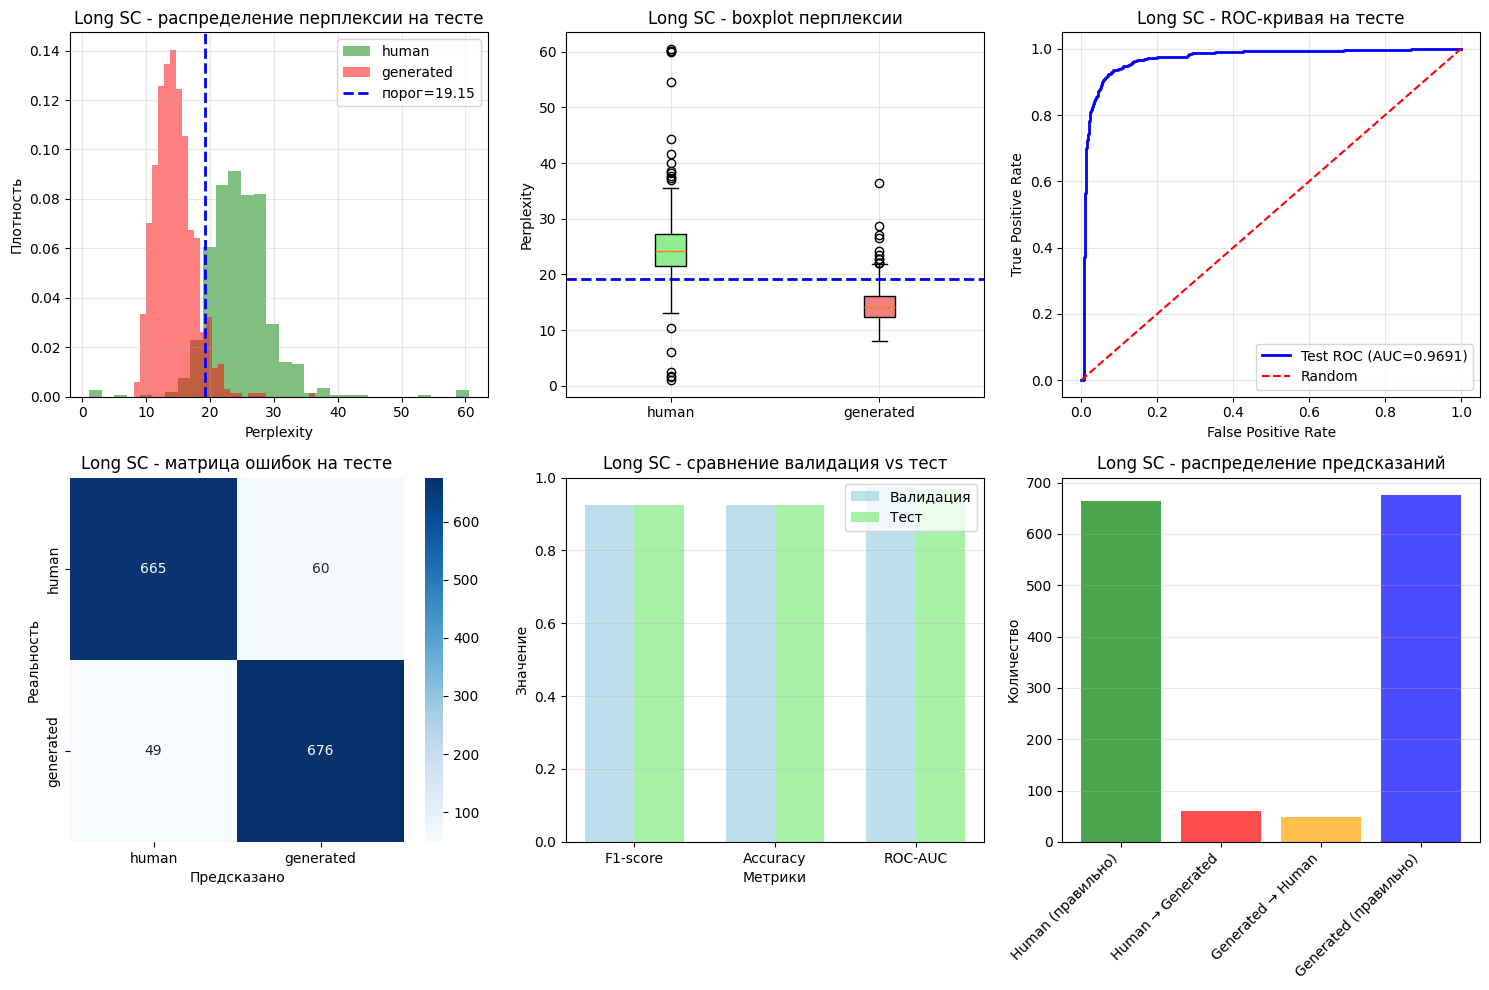

In [77]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, confusion_matrix
import seaborn as sns

# Подготавливаем данные для визуализации
test_human_ppl = test_human_ppl
test_machine_ppl = test_gen_ppl
y_test_true = [0]*len(test_human_ppl) + [1]*len(test_machine_ppl)
y_test_score = -np.array(test_human_ppl + test_machine_ppl)
final_threshold = best_thresh_f1

plt.figure(figsize=(15, 10))

# 1. Распределение перплексии на тесте
plt.subplot(2, 3, 1)
plt.hist(test_human_ppl, bins=30, alpha=0.5, label='human', density=True, color='green')
plt.hist(test_machine_ppl, bins=30, alpha=0.5, label='generated', density=True, color='red')
plt.axvline(x=final_threshold, color='blue', linestyle='--', linewidth=2, 
            label=f'порог={final_threshold:.2f}')
plt.xlabel('Perplexity')
plt.ylabel('Плотность')
plt.title('Long SC - распределение перплексии на тесте')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Boxplot
plt.subplot(2, 3, 2)
data_to_plot = [test_human_ppl, test_machine_ppl]
bp = plt.boxplot(data_to_plot, labels=['human', 'generated'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
plt.axhline(y=final_threshold, color='blue', linestyle='--', linewidth=2)
plt.ylabel('Perplexity')
plt.title('Long SC - boxplot перплексии')
plt.grid(True, alpha=0.3)

# 3. ROC-кривая
plt.subplot(2, 3, 3)
fpr_test, tpr_test, _ = roc_curve(y_test_true, y_test_score)
plt.plot(fpr_test, tpr_test, 'b-', linewidth=2, label=f'Test ROC (AUC={test_auc:.4f})')
plt.plot([0,1], [0,1], 'r--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Long SC - ROC-кривая на тесте')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Матрица ошибок
plt.subplot(2, 3, 4)
cm = confusion_matrix(y_test_true, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['human', 'generated'], 
            yticklabels=['human', 'generated'])
plt.xlabel('Предсказано')
plt.ylabel('Реальность')
plt.title('Long SC - матрица ошибок на тесте')

# 5. Сравнение метрик валидация vs тест
plt.subplot(2, 3, 5)
metrics = ['F1-score', 'Accuracy', 'ROC-AUC']
val_values = [best_f1, best_acc, val_auc]
test_values = [test_f1, test_acc, test_auc]
x = np.arange(len(metrics))
width = 0.35
plt.bar(x - width/2, val_values, width, label='Валидация', color='lightblue', alpha=0.8)
plt.bar(x + width/2, test_values, width, label='Тест', color='lightgreen', alpha=0.8)
plt.xlabel('Метрики')
plt.ylabel('Значение')
plt.title('Long SC - сравнение валидация vs тест')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.ylim([0, 1])

# 6. Предсказания по классам
plt.subplot(2, 3, 6)
labels = ['Human (правильно)', 'Human → Generated', 'Generated → Human', 'Generated (правильно)']
values = [cm[0,0], cm[0,1], cm[1,0], cm[1,1]]
colors = ['green', 'red', 'orange', 'blue']
plt.bar(labels, values, color=colors, alpha=0.7)
plt.ylabel('Количество')
plt.title('Long SC - распределение предсказаний')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [83]:
import pandas as pd

df_summary = pd.DataFrame([
    {
        'Домен': 'News[порог f1]',
        'Порог (F1)': news_results['threshold_f1'],
        'Порог (Acc)': news_results['threshold_acc'],
        'F1 (тест)': news_results['test_f1'],
        'Acc (тест)': news_results['test_acc'],
        'AUC (тест)': news_results['test_auc']
    },
    {
        'Домен': 'Essay[порог f1]',
        'Порог (F1)': essay_results['threshold_f1'],
        'Порог (Acc)': essay_results['threshold_acc'],
        'F1 (тест)': essay_results['test_f1'],
        'Acc (тест)': essay_results['test_acc'],
        'AUC (тест)': essay_results['test_auc']
    },
    {
        'Домен': 'Scientific[порог acc]',
        'Порог (F1)': sci_results['threshold_f1'],
        'Порог (Acc)': sci_results['threshold_acc'],
        'F1 (тест)': sci_results['test_f1'],
        'Acc (тест)': sci_results['test_acc'],
        'AUC (тест)': sci_results['test_auc']
    },
    {
        'Домен': 'Long SC[порог f1]',
        'Порог (F1)': long_results['threshold_f1'],
        'Порог (Acc)': long_results['threshold_acc'],
        'F1 (тест)': long_results['test_f1'],
        'Acc (тест)': long_results['test_acc'],
        'AUC (тест)': long_results['test_auc']
    }
])

print("\n" + "="*100)
print("Сводная таблица")
print("="*100)
print(df_summary.to_string(index=False, float_format='%.4f'))


Сводная таблица
                Домен  Порог (F1)  Порог (Acc)  F1 (тест)  Acc (тест)  AUC (тест)
       News[порог f1]     22.3088      21.8115     0.7297      0.7083      0.7990
      Essay[порог f1]     17.9227      17.8322     0.7742      0.7958      0.8256
Scientific[порог acc]     16.0019      13.6777     0.7304      0.7417      0.8073
    Long SC[порог f1]     19.1494      18.5665     0.9254      0.9248      0.9691


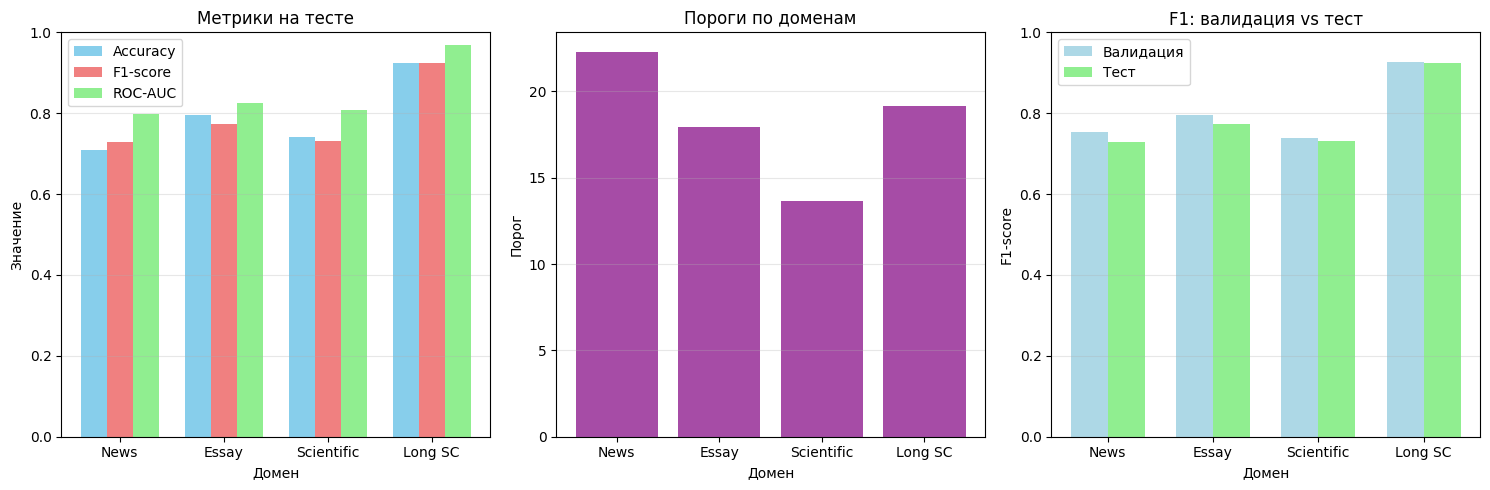

In [84]:
import matplotlib.pyplot as plt
import numpy as np

domains = ['News', 'Essay', 'Scientific', 'Long SC']
test_f1 = [news_results['test_f1'], essay_results['test_f1'], sci_results['test_f1'], long_results['test_f1']]
test_acc = [news_results['test_acc'], essay_results['test_acc'], sci_results['test_acc'], long_results['test_acc']]
test_auc = [news_results['test_auc'], essay_results['test_auc'], sci_results['test_auc'], long_results['test_auc']]
thresholds = [news_results['threshold_f1'], essay_results['threshold_f1'], sci_results['threshold_acc'], long_results['threshold_f1']]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
x = np.arange(len(domains))
width = 0.25
plt.bar(x - width, test_acc, width, label='Accuracy', color='skyblue')
plt.bar(x, test_f1, width, label='F1-score', color='lightcoral')
plt.bar(x + width, test_auc, width, label='ROC-AUC', color='lightgreen')
plt.xlabel('Домен')
plt.ylabel('Значение')
plt.title('Метрики на тесте')
plt.xticks(x, domains)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.ylim([0, 1])

plt.subplot(1, 3, 2)
plt.bar(domains, thresholds, color='purple', alpha=0.7)
plt.xlabel('Домен')
plt.ylabel('Порог')
plt.title('Пороги по доменам')
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 3, 3)
val_f1 = [news_results['val_f1'], essay_results['val_f1'], sci_results['val_f1'], long_results['val_f1']]
x = np.arange(len(domains))
width = 0.35
plt.bar(x - width/2, val_f1, width, label='Валидация', color='lightblue')
plt.bar(x + width/2, test_f1, width, label='Тест', color='lightgreen')
plt.xlabel('Домен')
plt.ylabel('F1-score')
plt.title('F1: валидация vs тест')
plt.xticks(x, domains)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.ylim([0, 1])

plt.tight_layout()
plt.show()